# The Fenna–Matthews–Olson (FMO) complex


The FMO complex is a a water-soluble complex found in green sulfur bacteria. It plays a key role in photosynthesis by mediating energy transfer between light-absorbing components, and this process can be modeled as an open quantum system.

The FMO complex is modeled as a network of sites (usually 7 or 8), each representing a bacteriochlorophyll molecule. The system Hamiltonian is written as:

$$
H_S=\sum_n\epsilon_n \ket{n}\bra{n}+ \sum_{n\ne m}J_{nm}\ket{n}\bra{m}
$$

where $\epsilon_n$ are site energies and $J_{nm}$ are electronic couplings between sites.

From the open system perspective, the FMO model provides a canonical example of excitation energy transfer in a noisy, dissipative environment allowing us to study. For the system-bath interaction, each FMO site $n$ is coupled to a local bosonic bath representing protein and solvent motions:

$$
H_{SB}=\sum_n \ket{n}\bra{n}\otimes \sum_jg_{nj}(a_{nj}+a_{nj}^\dagger)
$$

Here are some key points in understanding the interacting Hamiltonian:
- Each site has its own local environment, and that environment only interacts with the system when the excitation is at that site.
- There are no transitions between different sites induced by the bath — only energy fluctuations (i.e. dephasing).
- Energy of each site is shifted because of the bath, which is similar to the “dressed state”.

## Setup

In [1]:
from math import ceil
import os
import json as json
import numpy as np
from tqdm import tqdm

from tenso.prototypes.heom import system_multibath
from tenso.prototypes.bath import gen_bcf
import matplotlib.pyplot as plt

## Bath Correlation Function (BCF)

The bath correlation function encodes all the essential information required to capture the influence of the environment on the reduced density matrix of the system, $\rho_S(t)$. It is defined as

$$
C(t)=\mathrm{Tr}\bigl(\tilde{X}_B(t)\,\tilde{X}_B(0)\,\rho_B^{\mathrm{eq}}\bigr),
$$

and is related to the spectral density $J(\omega)$ through

$$
C(t)=\int_{-\infty}^{\infty} \mathcal{J}(\omega)(1-e^{-\beta \omega})^{-1}e^{-i\omega t}\mathrm{d}\omega
$$

where $\mathcal{J}(\omega) = \sum_j \frac{|c_j|^2}{2m_j\omega_j}[\delta(\omega-\omega_j)-\delta(\omega+\omega_j)]$ is the odd extension of $J(\omega)$, a quantity that summarizes the bath oscillator frequencies $\{\omega_j\}$ and their coupling strengths to the system.

In this example, each FMO site is coupled to a local Drude-Lorentz bath:

$$
J(\omega) = \frac{2\lambda}{\pi} \frac{\omega_c \omega}{\omega^2 + \omega_c^2},
$$

describing an Ohmic environment with reorganization energy $\lambda$ and cutoff frequency $\omega_c$. TENSO provides two approaches for decomposing the bath correlation function into sums of exponentials: the Matsubara and the Padé schemes. In this example, we focus on the Padé decomposition following the $\left( N - 1 \right)/N$ scheme. In general, such decompositions take the form

$$
C(t) = \sum_{k=1}^{K} c_k e^{  \gamma_k t}\quad \mathrm{and} \quad C^*(t) = \sum_{k=1}^{K} \bar{c_k} e^{  \gamma_k t}
$$

The `get_bcf` function accepts different arguments depending on the choice of spectral density and decomposition method. For a Drude-Lorentz spectral density combined with a Padé decomposition, the main parameters are:

- `re_d`: The Drude-Lorentz reorganization energy, $\lambda$. This parameter should be provided as a list.
- `width_d`: The cutoff frequency for the Drude-Lorentz SD, also specified as a list.
- `temperature`: The bath temperature in K (float).
- `decomposition_method`: The method used for the decomposition of the BCF (string).
- `n_ltc`: The number of low-temperature corrections.

In [2]:
bath = gen_bcf(
        re_d=[35.0], #Here we only consider the Drude-Lorentz Bath
        width_d=[106.17674918],
        temperature=300,
        decomposition_method='Pade',
        n_ltc=1,
    )

## The Hamiltonian of the FMO complex and the initial state

In [3]:
h = np.array([[200, -87.7, 5.5],
              [-87.7, 320, 30.8],
              [5.5, 30.8, -15]],
                 dtype=np.complex128) #This is the system Hamiltonian of the FMO complex
    
avg = np.diag(h).mean()
h -= avg * np.eye(3) # Shifting the Hamiltonian’s diagonal by subtracting the average energy, convenient for computation


sys_ops = []
end_time = 10000.0
dt = 1
for i in range(3):
    op_i = np.zeros((3, 3))
    op_i[i, i] = 1.0
    sys_ops.append(op_i) # The system operator of a site is a list of projective operators [|n><n|]

wfn = np.zeros(3)
wfn[0] = 1.0 #The initial state is a site state in site_1

## System-Multibath Propagator

**TENSO** provides the function `system_multibath()` to simulate open quantum systems in which different sites are coupled to distinct baths. An example of such system is the FMO model described above. This function gathers all parameters related to the system, the propagation scheme, and the influence of the baths on the system dynamics.

- `fname`: Specifies the output file name. In this example, it is `"3_level_FMO"`, corresponding to the `out` variable.
- `init_rdo`: Represents the outer product between $|\Psi\rangle$ and $\langle \Psi|$. Here, $|\Psi\rangle$ corresponds to the `wfn` variable. This argument defines the initial state of the system. In this example, the initial state is the site state in site_1.
- `sys_ham`: The system Hamiltonian. In this example, we shift the Hamiltonian’s diagonal elements by subtracting the average energy, which is for computation purpose. 
- `sys_op`: The system operator ($Q_S$) entering the system-bath interaction Hamiltonian ($H_{SB}$). Each site couples to its own bath, so each site-bath coupling has its own system operator. `sys_op` should be a list of system operators where each system operator is associated to a site and a bath. In this example, each element is the projective operator on the site state, expressed as $\ket{n}\bra{n}$. 
- `bath_correlation`: The bath correlation function (BCF) is a list of `bath` variables. In the list, each element is a seperated bath created by `get_bcf()`, coupled to the corresponding site through the interaction Hamiltonian.
- `dim`: The hierarchy depth. Higher values of `dim` typically yield more accurate results.
- `end_time`: Final time of the simulation.
- `step_time`: Time step (`dt`) used for propagation.

`**tqdm**` is employed to display the progress bar during the simulation runtime.

In [ ]:

out = "3_level_FMO"
propagator = system_multibath( 
        fname=out,
        init_rdo=np.outer(wfn, wfn.conj()),
        sys_ham=h,
        sys_ops=sys_ops,
        bath_correlations=[bath] * 3, #Each site has its own bath, different baths are seperated and independent
        end_time=end_time,
        step_time=dt,
        dim=10
    )

progress_bar = tqdm(propagator, total=ceil(end_time / dt)) #Show the progress bar
for _t in (progress_bar):
    progress_bar.set_description(f'@{_t:.2f} fs')

## Plotting the Results

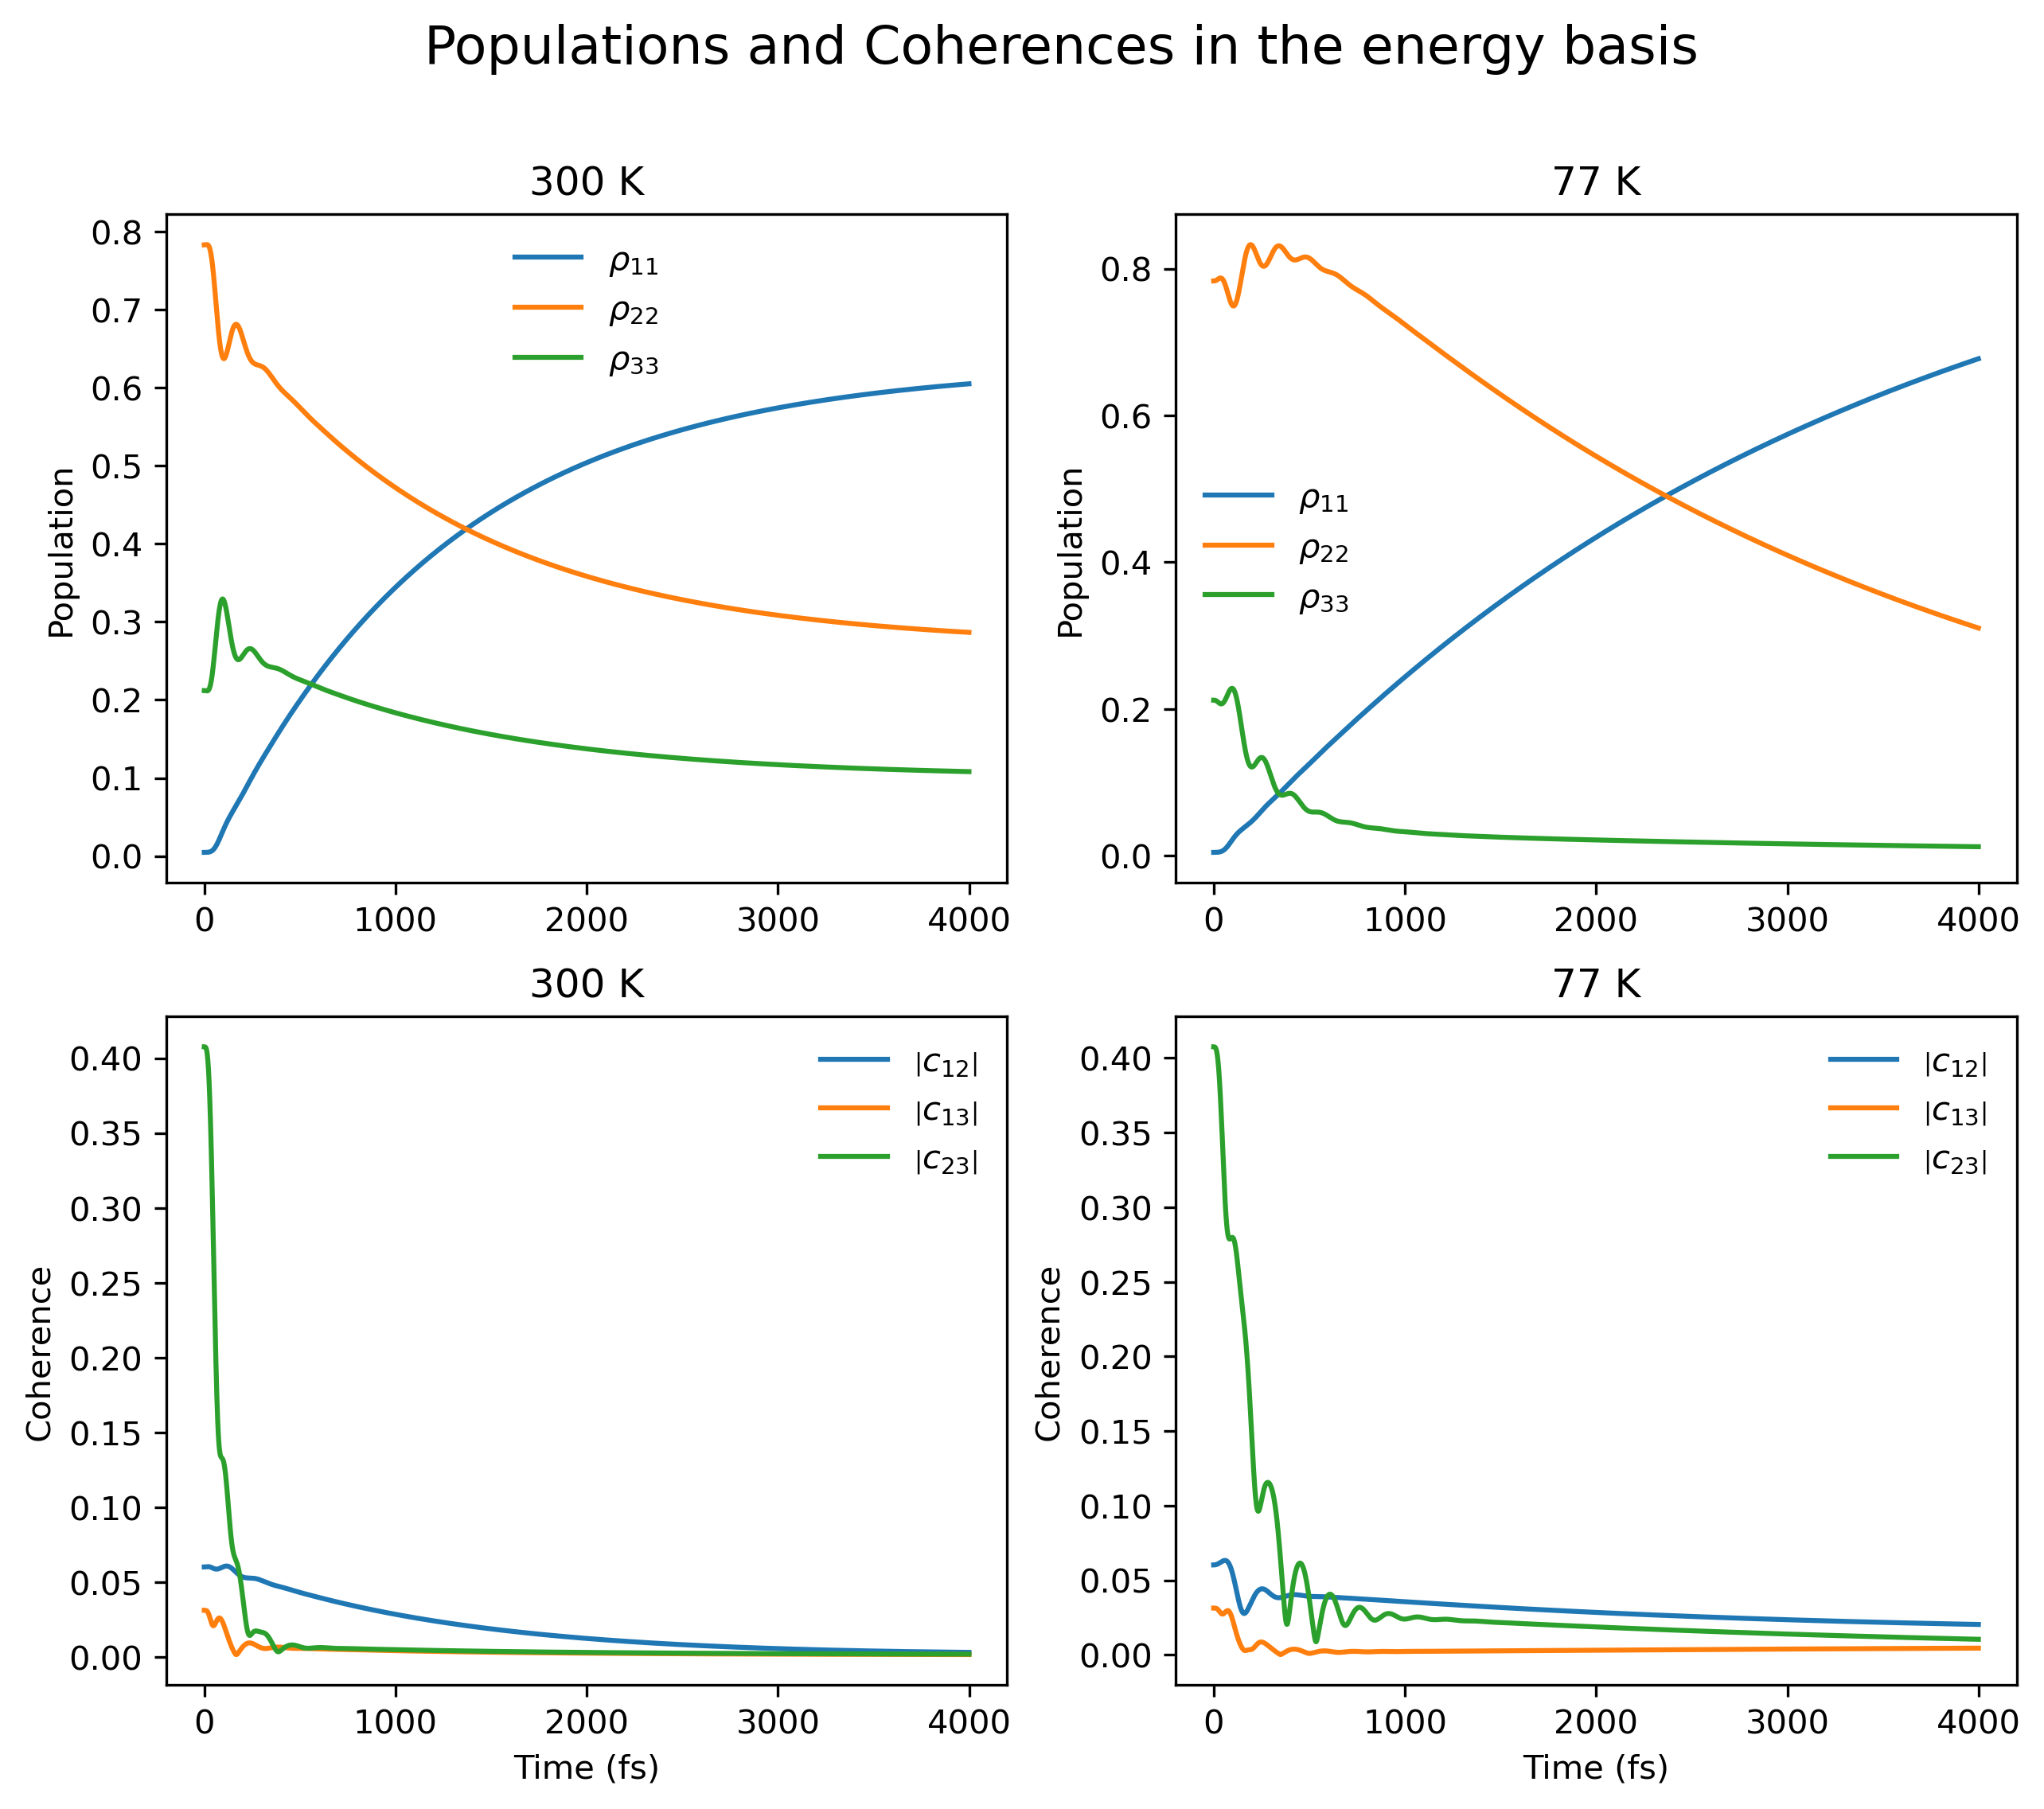

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Get the directory where the current script is located
current_dir = os.getcwd()
log_path_1 = os.path.join(current_dir, '3_level_300K.dat.log')
log_path_2 = os.path.join(current_dir, '3_level_77K.dat.log')

data_1=np.loadtxt(log_path_1,dtype=complex)
data_2=np.loadtxt(log_path_2,dtype=complex)

H = np.array([[200, -87.7, 5.5],
                [-87.7, 320, 30.8],
                [5.5, 30.8, -15]],
                dtype=np.complex128)
eigenvalues, U = np.linalg.eigh(H) #Diagonlize the Hamiltonian

c12_1=[]
c13_1=[]
c23_1=[]

c12_2=[]
c13_2=[]
c23_2=[]

p11_1=[]
p22_1=[]
p33_1=[]
t_1=[]

p11_2=[]
p22_2=[]
p33_2=[]
t_2=[]

for i in range(data_1.shape[0]):
    rho_t_1=np.array([[data_1[i][1],data_1[i][2],data_1[i][3]],[data_1[i][4],data_1[i][5],data_1[i][6]],[data_1[i][7],data_1[i][8],data_1[i][9]]])
    rho_1 = U.conj().T @ rho_t_1 @ U
    c12_1.append(abs(rho_1[0][1]))
    c13_1.append(abs(rho_1[0][2]))
    c23_1.append(abs(rho_1[1][2]))
    p11_1.append(rho_1[0][0].real)
    p22_1.append(rho_1[1][1].real)
    p33_1.append(rho_1[2][2].real)
    t_1.append(data_1[i][0].real)

    rho_t_2=np.array([[data_2[i][1],data_2[i][2],data_2[i][3]],[data_2[i][4],data_2[i][5],data_2[i][6]],[data_2[i][7],data_2[i][8],data_2[i][9]]])
    rho_2 = U.conj().T @ rho_t_2 @ U
    c12_2.append(abs(rho_2[0][1]))
    c13_2.append(abs(rho_2[0][2]))
    c23_2.append(abs(rho_2[1][2]))
    p11_2.append(rho_2[0][0].real)
    p22_2.append(rho_2[1][1].real)
    p33_2.append(rho_2[2][2].real)
    t_2.append(data_2[i][0].real)
    
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False,dpi=300)
ax1, ax2 ,ax3,ax4= axes.flatten()

N_1=10000
ax1.plot(t_1[:N_1],p11_1[:N_1], label=r'$\rho_{11}$',color="C0")
ax1.plot(t_1[:N_1],p22_1[:N_1], label=r'$\rho_{22}$',color="C1")
ax1.plot(t_1[:N_1],p33_1[:N_1], label=r'$\rho_{33}$',color="C2")
ax1.set_ylabel("Population")
ax1.set_title('300 K')
ax1.legend(frameon=False)
ax1.grid(False)

N_2=10000
ax2.plot(t_2[:N_2],p11_2[:N_2], label=r'$\rho_{11}$',color="C0")
ax2.plot(t_2[:N_2],p22_2[:N_2], label=r'$\rho_{22}$',color="C1")
ax2.plot(t_2[:N_2],p33_2[:N_2], label=r'$\rho_{33}$',color="C2")
ax2.set_ylabel("Population")
ax2.set_title('77 K')
ax2.legend(frameon=False)
ax2.grid(False)

N_3=10000
ax3.plot(t_1[:N_3],c12_1[:N_3], label=r'$\left | c_{12} \right |$',color="C0")
ax3.plot(t_1[:N_3],c13_1[:N_3], label=r'$\left | c_{13} \right |$',color="C1")
ax3.plot(t_1[:N_3],c23_1[:N_3], label=r'$\left | c_{23} \right |$',color="C2")
ax3.set_xlabel("Time (fs)")
ax3.set_ylabel("Coherence")
ax3.set_title('300 K')
ax3.legend(frameon=False)
ax3.grid(False)

N_4=10000
ax4.plot(t_2[:N_4],c12_2[:N_4], label=r'$\left | c_{12} \right |$',color="C0")
ax4.plot(t_2[:N_4],c13_2[:N_4], label=r'$\left | c_{13} \right |$',color="C1")
ax4.plot(t_2[:N_4],c23_2[:N_4], label=r'$\left | c_{23} \right |$',color="C2")
ax4.set_xlabel("Time (fs)")
ax4.set_ylabel("Coherence")
ax4.set_title('77 K')
ax4.legend(frameon=False)
ax4.grid(False)

fig.suptitle('Populations and Coherences in the energy basis', fontsize=16)
plt.savefig('3_level_FMO_Model_site_basis.png', dpi=300, transparent=True)
plt.show()



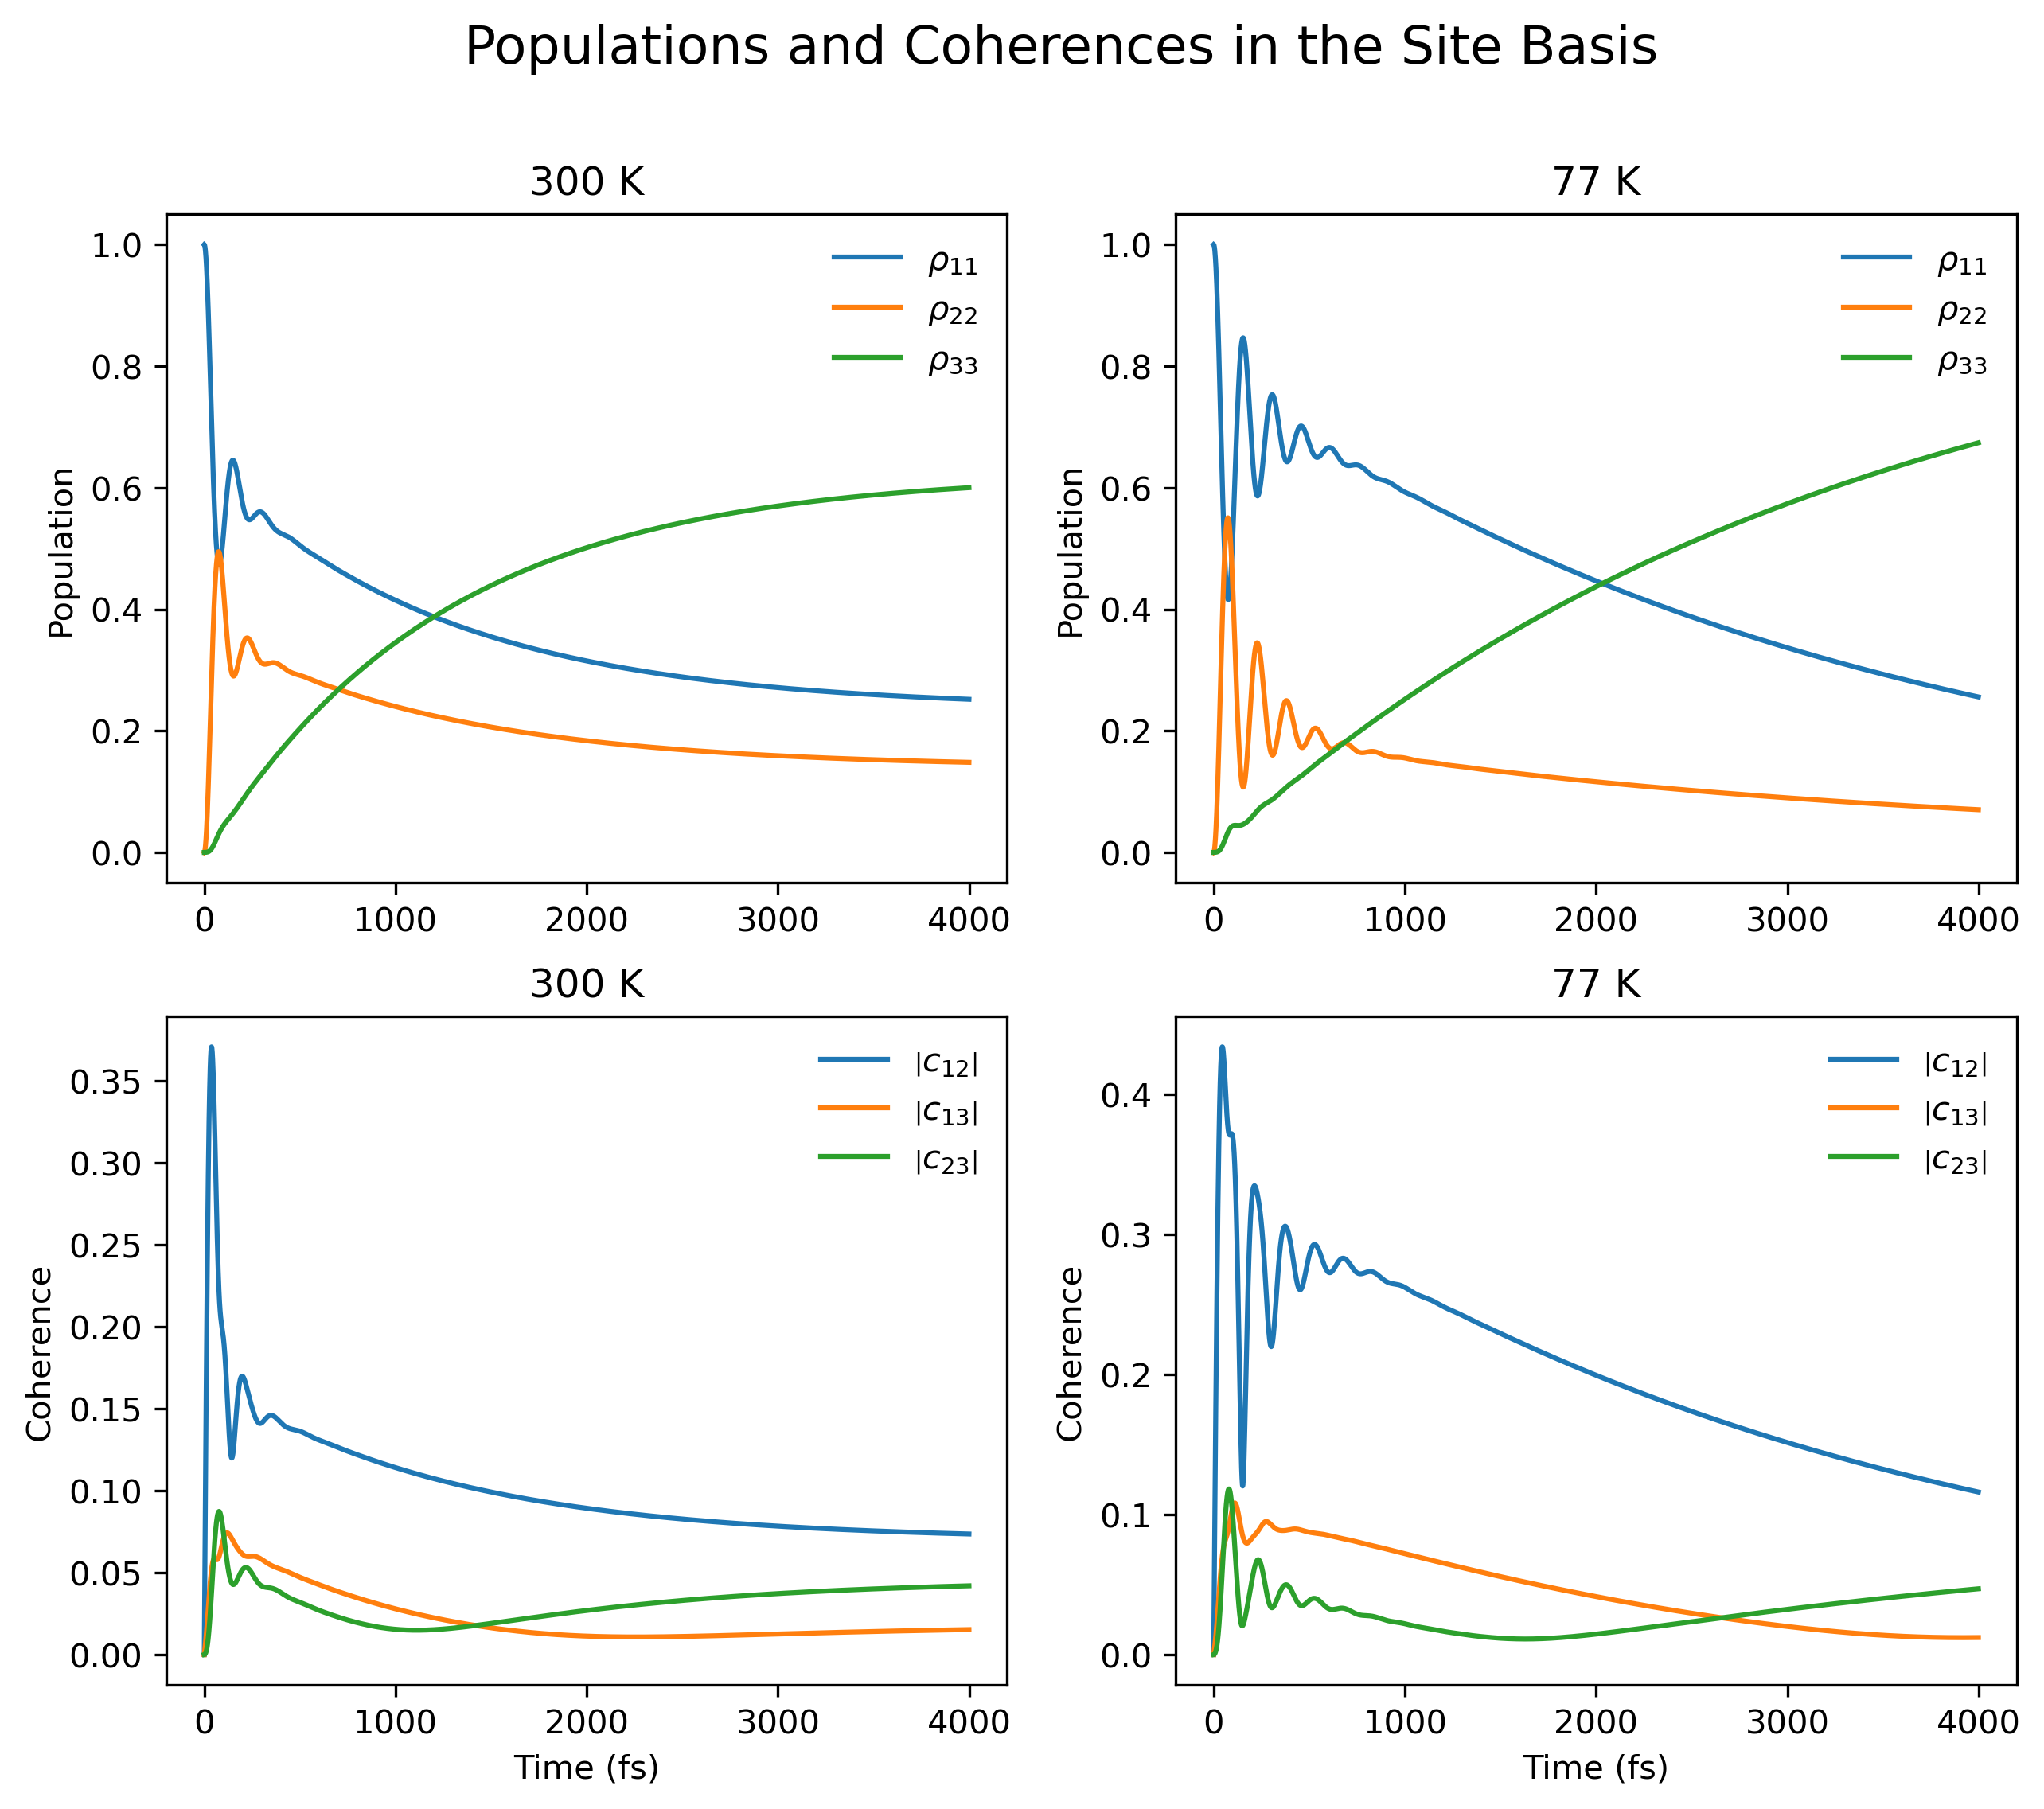

In [8]:
p11_1=[]
p22_1=[]
p33_1=[]
t_1=[]

p11_2=[]
p22_2=[]
p33_2=[]
t_2=[]

c12_1=[]
c13_1=[]
c23_1=[]

c12_2=[]
c13_2=[]
c23_2=[]

for i in range(data_1.shape[0]):
    p11_1.append(data_1[i][1].real)
    p22_1.append(data_1[i][5].real)
    p33_1.append(data_1[i][9].real)
    t_1.append(data_1[i][0].real)
    p11_2.append(data_2[i][1].real)
    p22_2.append(data_2[i][5].real)
    p33_2.append(data_2[i][9].real)
    t_2.append(data_2[i][0].real)

    c12_1.append(abs(data_1[i][2]))
    c13_1.append(abs(data_1[i][3]))
    c23_1.append(abs(data_1[i][6]))

    c12_2.append(abs(data_2[i][2]))
    c13_2.append(abs(data_2[i][3]))
    c23_2.append(abs(data_2[i][6]))


    

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False,dpi=300)
ax1, ax2 ,ax3,ax4= axes.flatten()

N_1=10000
ax1.plot(t_1[:N_1],p11_1[:N_1], label=r'$\rho_{11}$',color="C0")
ax1.plot(t_1[:N_1],p22_1[:N_1], label=r'$\rho_{22}$',color="C1")
ax1.plot(t_1[:N_1],p33_1[:N_1], label=r'$\rho_{33}$',color="C2")
ax1.set_ylabel("Population")
ax1.set_title('300 K')
ax1.legend(frameon=False)
ax1.grid(False)

N_2=10000
ax2.plot(t_2[:N_2],p11_2[:N_2], label=r'$\rho_{11}$',color="C0")
ax2.plot(t_2[:N_2],p22_2[:N_2], label=r'$\rho_{22}$',color="C1")
ax2.plot(t_2[:N_2],p33_2[:N_2], label=r'$\rho_{33}$',color="C2")
ax2.set_ylabel("Population")
ax2.set_title('77 K')
ax2.legend(frameon=False)
ax2.grid(False)


N_3=10000
ax3.plot(t_1[:N_3],c12_1[:N_3], label=r'$\left | c_{12} \right |$',color="C0")
ax3.plot(t_1[:N_3],c13_1[:N_3], label=r'$\left | c_{13} \right |$',color="C1")
ax3.plot(t_1[:N_3],c23_1[:N_3], label=r'$\left | c_{23} \right |$',color="C2")
ax3.set_xlabel("Time (fs)")
ax3.set_ylabel("Coherence")
ax3.set_title('300 K')
ax3.legend(frameon=False)
ax3.grid(False)

N_4=10000
ax4.plot(t_2[:N_4],c12_2[:N_4], label=r'$\left | c_{12} \right |$',color="C0")
ax4.plot(t_2[:N_4],c13_2[:N_4], label=r'$\left | c_{13} \right |$',color="C1")
ax4.plot(t_2[:N_4],c23_2[:N_4], label=r'$\left | c_{23} \right |$',color="C2")
ax4.set_xlabel("Time (fs)")
ax4.set_ylabel("Coherence")
ax4.set_title('77 K')
ax4.legend(frameon=False)
ax4.grid(False)

fig.suptitle('Populations and Coherences in the Site Basis', fontsize=16)
plt.savefig('3_level_FMO_Model_energy_basis.png', dpi=300, transparent=True)
plt.show()
